<a href="https://colab.research.google.com/github/omar192501/predict_of_ride_acceptance/blob/main/predict_of_ride_acceptance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
df = pd.DataFrame({
    "pickup_distance_km": [1.2,2.5,0.8,3.0,1.5,2.8,1.0,3.5,1.6,2.2],
    "surge_multiplier": [1.1,1.0,1.3,1.0,1.2,1.0,1.4,1.0,1.3,1.1],
    "passenger_rating": [4.7,4.5,4.9,4.6,4.8,4.4,4.9,4.3,4.8,4.6],
    "traffic_index": [35,42,30,50,37,48,28,55,38,44],
    "accept": [1,0,1,0,1,0,1,0,1,0]
})

display(df.head())

,pickup_distance_km,surge_multiplier,passenger_rating,traffic_index,accept
0,1.2,1.1,4.7,35,1
1,2.5,1.0,4.5,42,0
2,0.8,1.3,4.9,30,1
3,3.0,1.0,4.6,50,0
4,1.5,1.2,4.8,37,1


In [11]:
x=df.drop(['accept'],axis=1)
y=df['accept']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
display(x_train,x_test,y_train,y_test)

,pickup_distance_km,surge_multiplier,passenger_rating,traffic_index
6,1.0,1.4,4.9,28
9,2.2,1.1,4.6,44
3,3.0,1.0,4.6,50
1,2.5,1.0,4.5,42
2,0.8,1.3,4.9,30
0,1.2,1.1,4.7,35
4,1.5,1.2,4.8,37
5,2.8,1.0,4.4,48


,pickup_distance_km,surge_multiplier,passenger_rating,traffic_index
7,3.5,1.0,4.3,55
8,1.6,1.3,4.8,38


,accept
6,1
9,0
3,0
1,0
2,1
0,1
4,1
5,0


,accept
7,0
8,1


In [20]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)
model=LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

In [13]:
y_pred=model.predict(x_test)
display(y_pred)
acc=accuracy_score(y_test,y_pred)
cm=confusion_matrix(y_test,y_pred)
report=classification_report(y_test,y_pred)
print("accuracy_score:",acc)
print("confusion_matrix:",cm)
print("classification_report:",report)

array([0, 1])

accuracy_score: 1.0
confusion_matrix: [[1 0]
 [0 1]]
classification_report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



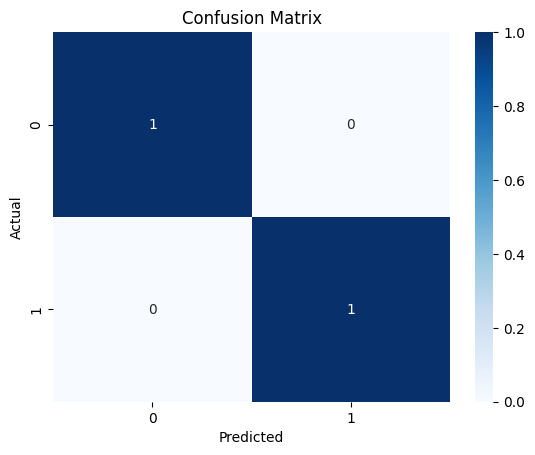

In [14]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [15]:
new_request = pd.DataFrame([[1.6, 1.3, 4.8, 38]],columns=["pickup_distance_km", "surge_multiplier", "passenger_rating", "traffic_index"])
new_scaled = scaler.transform(new_request)
prediction = model.predict(new_scaled)
print("Will driver accept:", prediction[0])

Will driver accept: 1
